In [8]:
# ═══════════════════════════════════════════════
# Notebook 01 — Data Exploration
# Author: Ali Solangi
# ═══════════════════════════════════════════════

# Cell 1 — Setup
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob

BASE_PATH     = "/content/drive/MyDrive/Original Reddit Data"
RAW_PATH      = os.path.join(BASE_PATH, "raw data")
LABELLED_PATH = "/content/drive/MyDrive/outputs"

print("Setup complete")
print(f"Years available: {os.listdir(RAW_PATH)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup complete
Years available: ['2022', '2019', '2021', '2020']


In [17]:
import pandas as pd
import os

LABELLED_PATH = "/content/drive/MyDrive/Original Reddit Data/Labelled Data"
SAVE_PATH     = "/content/drive/MyDrive/"

label_files = {
    "Drug and Alcohol" : LABELLED_PATH + "/LD DA 1.csv",
    "Early Life"       : LABELLED_PATH + "/LD EL1.csv",
    "Personality"      : LABELLED_PATH + "/LD PF1.csv",
    "Trauma and Stress": LABELLED_PATH + "/LD TS 1.csv"
}

dfs_b = []
for label, filepath in label_files.items():
    try:
        temp = pd.read_csv(filepath)
        temp['Label'] = label
        dfs_b.append(temp)
        print(f"✓ {label}: {temp.shape[0]} rows")
    except Exception as e:
        print(f"✗ {label}: {e}")

df_b = pd.concat(dfs_b, ignore_index=True)
df_b = df_b.dropna(subset=['selftext'])
if 'CAT 1' in df_b.columns:
    df_b = df_b.drop(columns=['CAT 1'])

df_b['full_text']  = df_b['title'].fillna('') + ' ' + df_b['selftext'].fillna('')

print(f"\nPart B shape: {df_b.shape}")
print(f"Labels:\n{df_b['Label'].value_counts()}")

✓ Drug and Alcohol: 223 rows
✓ Early Life: 200 rows
✓ Personality: 200 rows
✓ Trauma and Stress: 200 rows

Part B shape: (800, 6)
Labels:
Label
Drug and Alcohol     200
Early Life           200
Personality          200
Trauma and Stress    200
Name: count, dtype: int64


In [18]:
# Cell 3 — Missing values and basic stats
print("=== MISSING VALUES ===")
print(df_sample.isnull().sum())

print("\n=== SUBREDDIT DISTRIBUTION ===")
print(df_sample['subreddit'].value_counts().head(10))

print("\n=== POST LENGTH STATS ===")
print(df_sample['selftext'].dropna().str.len().describe())

=== MISSING VALUES ===
Unnamed: 0        0
author            0
created_utc       0
score             0
selftext       1154
subreddit         0
title             0
timestamp         0
date              0
dtype: int64

=== SUBREDDIT DISTRIBUTION ===
subreddit
depression      14513
SuicideWatch     5877
Anxiety          5149
mentalhealth     3568
lonely           1011
Name: count, dtype: int64

=== POST LENGTH STATS ===
count    28964.000000
mean       920.538047
std       1164.189801
min          1.000000
25%        261.000000
50%        584.000000
75%       1149.250000
max      29175.000000
Name: selftext, dtype: float64


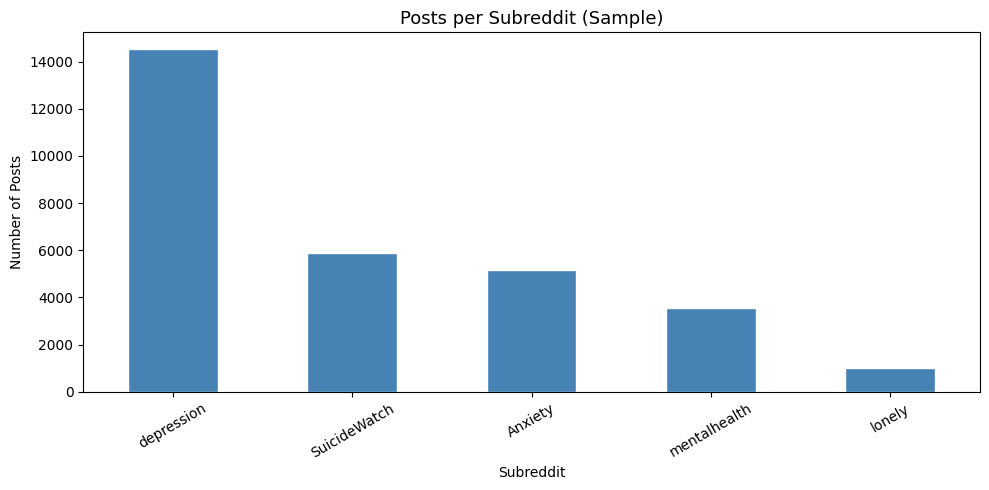

In [19]:
# Cell 4 — Subreddit distribution chart
fig, ax = plt.subplots(figsize=(10, 5))
valid = ['depression', 'SuicideWatch', 'mentalhealth', 'Anxiety', 'lonely']
counts = df_sample[df_sample['subreddit'].isin(valid)]['subreddit'].value_counts()
counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Posts per Subreddit (Sample)', fontsize=13)
ax.set_xlabel('Subreddit')
ax.set_ylabel('Number of Posts')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

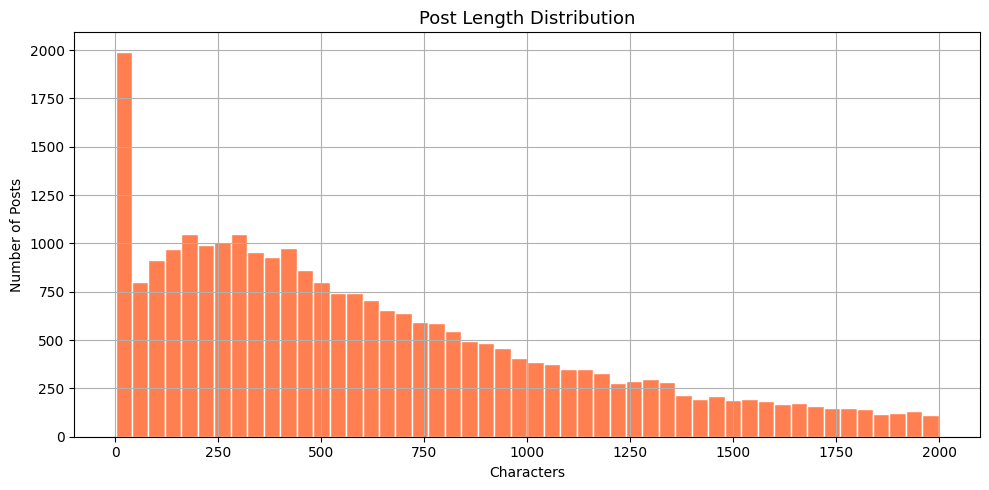

In [20]:
# Cell 5 — Post length distribution
fig, ax = plt.subplots(figsize=(10, 5))
lengths = df_sample['selftext'].dropna().str.len()
lengths[lengths < 2000].hist(bins=50, ax=ax, color='coral', edgecolor='white')
ax.set_title('Post Length Distribution', fontsize=13)
ax.set_xlabel('Characters')
ax.set_ylabel('Number of Posts')
plt.tight_layout()
plt.show()

In [21]:
# Cell 6 — Date range
df_sample['date'] = pd.to_datetime(df_sample['created_utc'], unit='s')
print(f"Earliest post: {df_sample['date'].min()}")
print(f"Latest post:   {df_sample['date'].max()}")
print(f"\nSample post text:")
print(df_sample['selftext'].dropna().iloc[0][:300])

Earliest post: 2019-02-28 13:04:28
Latest post:   2019-03-31 12:54:52

Sample post text:
[removed]


In [22]:
# Cell 7 — Load Part B
label_files = {
    "Drug and Alcohol" : LABELLED_PATH + "/LD DA 1.csv",
    "Early Life"       : LABELLED_PATH + "/LD EL1.csv",
    "Personality"      : LABELLED_PATH + "/LD PF1.csv",
    "Trauma and Stress": LABELLED_PATH + "/LD TS 1.csv"
}

dfs_b = []
for label, filepath in label_files.items():
    try:
        temp = pd.read_csv(filepath)
        temp['Label'] = label
        dfs_b.append(temp)
        print(f"✓ {label}: {temp.shape[0]} rows")
    except Exception as e:
        print(f"✗ {label}: {e}")

df_b = pd.concat(dfs_b, ignore_index=True)
print(f"\nPart B shape: {df_b.shape}")
print(f"\nLabel distribution:")
print(df_b['Label'].value_counts())

✓ Drug and Alcohol: 223 rows
✓ Early Life: 200 rows
✓ Personality: 200 rows
✓ Trauma and Stress: 200 rows

Part B shape: (823, 6)

Label distribution:
Label
Drug and Alcohol     223
Early Life           200
Personality          200
Trauma and Stress    200
Name: count, dtype: int64


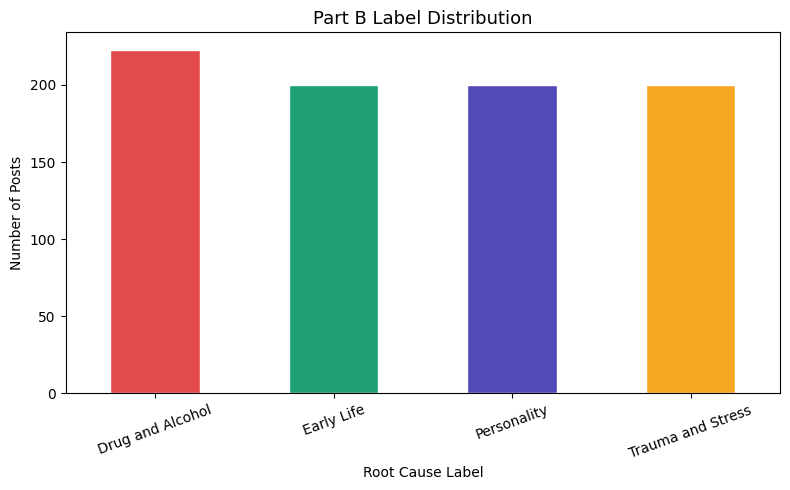

In [24]:
# Cell 8 — Part B chart
fig, ax = plt.subplots(figsize=(8, 5))
df_b['Label'].value_counts().plot(
    kind='bar', ax=ax,
    color=['#E24B4A', '#1D9E75', '#534AB7', '#F5A623'],
    edgecolor='white'
)
ax.set_title('Part B Label Distribution', fontsize=13)
ax.set_xlabel('Root Cause Label')
ax.set_ylabel('Number of Posts')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

In [26]:
# Cell 9 — Summary
print("=== EXPLORATION SUMMARY ===")
print(f"Part A sample rows: {df_sample.shape[0]:,}")
print(f"Part B total rows:  {df_b.shape[0]}")
print(f"Subreddits:         5")
print(f"Date range:         2019 to 2022")
print(f"Labels:             {df_b['Label'].nunique()} categories")


=== EXPLORATION SUMMARY ===
Part A sample rows: 30,118
Part B total rows:  823
Subreddits:         5
Date range:         2019 to 2022
Labels:             4 categories
